<a href="https://colab.research.google.com/github/k6jf8wfhxh-ux/Iris_classification/blob/main/lecture10_exercise_answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第10回講義 演習

今回は，自己教師あり学習の1つである[Masked Autoencoder](https://openaccess.thecvf.com/content/CVPR2022/papers/He_Masked_Autoencoders_Are_Scalable_Vision_Learners_CVPR_2022_paper.pdf)(MAE)を実装していきます．

---
# Lecture 10: Exercise

This time, we will implement [Masked Autoencoder](https://openaccess.thecvf.com/content/CVPR2022/papers/He_Masked_Autoencoders_Are_Scalable_Vision_Learners_CVPR_2022_paper.pdf) (MAE), which is a type of self-supervised learning.


## 目次
[【課題】Masked Autoencoderによる自己教師あり学習](#scrollTo=8as0HunPncwp)

1. [Transformer Blockの実装](#scrollTo=S6Os2crtMX5A)

1. [Masked Autoencoderの実装](#scrollTo=J-wkHNcLSog9)

1. [ヘルパー関数の実装](#scrollTo=xiGsQb31qmkm)

1. [学習・推論](#scrollTo=AeXCUI19wPx6)

1. [attention mapの可視化](#scrollTo=s4Mcwi2mLYvl)

1. [Linear probing](#scrollTo=g_DCP3exLYvm)  

　 [参考文献](#scrollTo=atZbN-d1LYvm)



---
## table of contents
[[Challenge] Self-supervised learning using Masked Autoencoder](#scrollTo=8as0HunPncwp)

1. [Transformer Block implementation](#scrollTo=S6Os2crtMX5A)

1. [Implementation of Masked Autoencoder](#scrollTo=J-wkHNcLSog9)

1. [Implementing helper functions](#scrollTo=xiGsQb31qmkm)

1. [Learning/reasoning](#scrollTo=AeXCUI19wPx6)

1. [Visualization of attention map](#scrollTo=s4Mcwi2mLYvl)

1. [Linear probing](#scrollTo=g_DCP3exLYvm)  

　 [References](#scrollTo=atZbN-d1LYvm)



## 【課題】Masked Autoencoderによる自己教師あり学習

---
## [Challenge] Self-supervised learning using Masked Autoencoder


MAEではEncoderに入力画像の一部のパッチのみ入力し，DecoderはパッチをEncodeした潜在表現と，学習可能なmask tokenを入力することでもとの画像を再構成するというモデルになっています．MAEの全体像は以下のようになっています．

![MAE overview](https://drive.google.com/uc?id=1pUymdnmbjXCTWmpfXDKgNqb-xi0I0xV2)

MAEのアーキテクチャではTransformerを用いるため，まずTransformer Blockの実装を行い，それらを用いてMAEを実装する流れになっています．



---
MAE has a model in which only some patches of the input image are input to the encoder, and the decoder reconstructs the original image by inputting a latent representation obtained by encoding the patches and a learnable mask token. The overall picture of MAE is as follows.

![MAE overview](https://drive.google.com/uc?id=1pUymdnmbjXCTWmpfXDKgNqb-xi0I0xV2)

The MAE architecture uses Transformers, so the flow is to first implement Transformer Blocks and then use them to implement MAE.



まずは必要なライブラリをimportし，シード値を固定しておきます．  
本演習では`einops`というライブラリを用います．これはテンソルに対する複雑な操作を直感的な記法で実装することができます．演習内では画像をパッチに分割するときや，Attention内でのテンソルの形状の変更，パッチから画像に戻す際に利用します．

document: https://github.com/arogozhnikov/einops

---
First, import the necessary libraries and fix the seed value.
In this exercise, we will use a library called `einops`. This allows complex operations on tensors to be implemented using an intuitive notation. In the exercise, it is used when dividing an image into patches, changing the shape of a tensor within Attention, and converting a patch back into an image.

document: https://github.com/arogozhnikov/einops


In [ ]:
!pip install einops

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import math
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from einops.layers.torch import Rearrange
from einops import rearrange

In [ ]:
# Setting the seed value
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

## 1.Transformer Blockの実装
第8回の演習とほとんど同じです．

---
## 1.Transformer Block implementation
This is almost the same as the 8th exercise.


**Multi-Head Attention**

TransformerのEncoderはSelf-Attentionになっており，Multi-Headの場合は以下のように表すことができます．

（The Transformer encoder is Self-Attention, and in the case of Multi-Head, it can be expressed as follows.）

\begin{align}
    Q_{i} &= W^Q_{i} X + b^Q_{i} \\
    K_{i} &= W^K_{i} X + b^K_{i} \\
    V_{i} &= W^V_{i} X + b^V_{i} \\
    head_{i} &= \text{Attention}_i(X) \\
    \text{Multi-Head Attention}(X) &= [head_1, head_2, \cdots , head_n]
\end{align}

In [ ]:
# Implementing Multi-Head Attention
class Attention(nn.Module):
    def __init__(self, dim, heads, dim_head, dropout=0.):
        """
        Arguments
        ---------
        dim : int
            入力データの次元数．埋め込み次元数と一致する
        heads : int
            ヘッドの数
        dim_head : int
            各ヘッドのデータの次元数
        dropout : float
            Dropoutの確率(default=0.)
        """
        super().__init__()

        self.dim = dim
        self.dim_head = dim_head
        inner_dim = dim_head * heads  # Number of dimensions of Q, K, and V before dividing into heads. May be different from self.dim
        project_out = not (heads == 1 and dim_head == dim)  # Normal Self-Attention if heads is 1 and dim_head is equal to dim

        self.heads = heads
        self.scale = math.sqrt(dim_head)  # Scaling factor (dim_k) before applying softmax function

        self.attend = nn.Softmax(dim=-1)  # Softmax function used to calculate attention score
        self.dropout = nn.Dropout(dropout)

        # Fully connected layer to convert to Q, K, V
        self.to_q = nn.Linear(in_features=dim, out_features=inner_dim)
        self.to_k = nn.Linear(in_features=dim, out_features=inner_dim)
        self.to_v = nn.Linear(in_features=dim, out_features=inner_dim)

        # If dim != inner_dim, insert a linear layer, otherwise output as is
        self.to_out = nn.Sequential(
            nn.Linear(in_features=inner_dim, out_features=dim),
            nn.Dropout(dropout),
        ) if project_out else nn.Identity()

    def forward(self, x):
        """
        B: バッチサイズ
        N: 系列長
        D: データの次元数(dim)
        """
        B, N, D = x.size()

        # Convert input data to Q, K, V
        # (B, N, dim) -> (B, N, inner_dim)
        q = self.to_q(x)
        k = self.to_k(x)
        v = self.to_v(x)

        # Split Q, K, V into heads
        # (B, N, inner_dim) -> (B, heads, N, dim_head)
        q = rearrange(q, "b n (h d) -> b h n d", h=self.heads, d=self.dim_head)
        k = rearrange(k, "b n (h d) -> b h n d", h=self.heads, d=self.dim_head)
        v = rearrange(v, "b n (h d) -> b h n d", h=self.heads, d=self.dim_head)

        # Calculate QK^T / sqrt(d_k)
        # (B, heads, N, dim_head) x (B, heads, dim_head, N) -> (B, heads, N, N)
        dots = torch.matmul(q, k.transpose(-2, -1)) / self.scale

        # Calculate the score using the softmax function and perform dropout
        attn = self.attend(dots)
        attn = self.dropout(attn)

        # Calculate softmax(QK^T / sqrt(d_k))V
        # (B, heads, N, N) x (B, heads, N, dim_head) -> (B, heads, N, dim_head)
        out = torch.matmul(attn ,v)

        # return to original shape
        # (B, heads, N, dim_head) -> (B, N, dim)
        out = rearrange(out, "b h n d -> b n (h d)", h=self.heads, d=self.dim_head)

        # If the dimensions are different, restore and output
        # Make sure to also return an attention map to visualize the expression.
        return self.to_out(out), attn

Multi-Head Attentionでは入力の形状と出力の形状が同じになります．実際に確認してみましょう．

今回は入力の次元数と，Attention処理をしたあとの次元数を同じにしています（dim = inner_dim）．

---
In Multi-Head Attention, the input shape and output shape are the same. Let's actually check it out.

This time, the number of dimensions of the input and the number of dimensions after attention processing are the same (dim = inner_dim).


In [ ]:
attn = Attention(384, 12, 32, 0.)
x = torch.rand(4, 64, 384)  # (B, N, D)
attn(x)[0].shape

torch.Size([4, 64, 384])

**Feed-Forward Network**

In [ ]:
# Implementation of Feed-Forward Network
class FFN(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.):
        """
        Arguments
        ---------
        dim : int
            入力データの次元数．
        hidden_dim : int
            隠れ層の次元．
        dropout : float
            各全結合層の後のDropoutの確率(default=0.)．
        """
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_features=dim, out_features=hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(in_features=hidden_dim, out_features=dim),
            nn.Dropout(dropout),
        )  # MLP with one hidden layer and uses GELU as the activation function

    def forward(self, x):
        """
        (B, D) -> (B, D)
        B: バッチサイズ
        D: 次元数
        """
        return self.net(x)

こちらもAttentionと同様に入力データの次元と出力データの次元は一致しています．実際に確認してみましょう．

---
Similarly to Attention, the dimensions of the input data and the dimensions of the output data match. Let's actually check it out.


In [ ]:
ffn = FFN(384, 768, 0.)
x = torch.rand(4, 64, 384)  # (B, N, D)
ffn(x).shape

torch.Size([4, 64, 384])

**Transformer Block**

上記で実装したAttention, FFNを用いてBlockを実装しましょう．

Blockは以下のような構造をしています．1つのBlockにはAttentionとFFNが1つずつ含まれており，それぞれLayer Normalizationをしてから処理を行い，skip connectionの構造を持っています．

![Block overview](https://drive.google.com/uc?id=1kZc0lCB0FGaht1hQHH8lHHEgAOKViHlE)

---
**Transformer Block**

Let's implement Block using Attention and FFN implemented above.

Block has the following structure. One Block contains one Attention and one FFN, each is processed after Layer Normalization, and has a skip connection structure.

![Block overview](https://drive.google.com/uc?id=1kZc0lCB0FGaht1hQHH8lHHEgAOKViHlE)


In [ ]:
class Block(nn.Module):
    def __init__(self, dim, heads, dim_head, mlp_dim, dropout):
        """
        TransformerのEncoder Blockの実装．

        Arguments
        ---------
        dim : int
            埋め込みされた次元数．PatchEmbedのembed_dimと同じ値．
        heads : int
            Multi-Head Attentionのヘッドの数．
        dim_head : int
            Multi-Head Attentionの各ヘッドの次元数．
        mlp_dim : int
            Feed-Forward Networkの隠れ層の次元数．
        dropout : float
            Droptou層の確率p．
        """
        super().__init__()

        self.attn_ln = nn.LayerNorm(dim)  # LayerNorm before Attention
        self.attn = Attention(dim, heads, dim_head, dropout)
        self.ffn_ln = nn.LayerNorm(dim)  # LayerNorm before FFN
        self.ffn = FFN(dim, mlp_dim, dropout)

    def forward(self, x, return_attn=False):
        """
        x: (B, N, dim)
        B: バッチサイズ
        N: 系列長
        dim: 埋め込み次元
        """
        y, attn = self.attn(self.attn_ln(x))
        if return_attn:  # Returns attention map (used to visualize attention map)
            return attn
        x = y + x
        out = self.ffn(self.ffn_ln(x)) + x

        return out

In [ ]:
block = Block(384, 12, 32, 384, 0.)
x = torch.rand(4, 64, 384)  # (B, N, D)
block(x).shape

torch.Size([4, 64, 384])

**Patch Embedding**

Transformerで画像を扱うために，Patch Embeddingを実装します．


---
**Patch Embedding**

Implement Patch Embedding to handle images with Transformer.


In [ ]:
# Implementing patch embedding
class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embed_dim):
        """
        入力画像をパッチごとに埋め込むための層．

        Arguments
        ---------
        image_size : Tuple[int]
            入力画像のサイズ．
        patch_size : Tuple[int]
            各パッチのサイズ．
        in_channels : int
            入力画像のチャネル数．
        embed_dim : int
            埋め込み後の次元数．
        """
        super().__init__()

        image_height, image_width = image_size
        patch_height, patch_width = patch_size

        assert image_height % patch_height == 0 and image_width % patch_width == 0, "パッチサイズは，入力画像のサイズを割り切れる必要があります．"

        num_patches = (image_height // patch_height) * (image_width // patch_width)  # number of patches
        patch_dim = in_channels * patch_height * patch_width  # Number of dimensions when flattening each patch

        self.to_patch_embedding = nn.Sequential(
            Rearrange("b c (h p1) (w p2) -> b (h w) (p1 p2 c)", p1=patch_height, p2=patch_width),  # Split image into patches and flatten
            nn.Linear(in_features=patch_dim, out_features=embed_dim),  # Embed
        )

    def forward(self, x):
        """
        B: バッチサイズ
        C: 入力画像のチャネル数
        H: 入力画像の高さ
        W: 入力画像の幅
        """
        return self.to_patch_embedding(x)  # (B, C, H, W) -> (B, num_patches, embed_dim)

動作確認として画像（CIFAR-10と同じ形状）を模したデータを入力してみましょう．出力として系列データと同様の形状になります．

---
To check the operation, let's input data that resembles an image (same shape as CIFAR-10). The output will have the same shape as the series data.


In [ ]:
patch_emb = PatchEmbedding((32, 32), (4, 4), 3, 384)
x = torch.rand((4, 3, 32, 32))  # (B, C, H, W)
patch_emb(x).shape

torch.Size([4, 64, 384])

## 2.Masked Autoencoderの実装
ここまででMAEを実装するためのコンポーネントを定義することができました．ここからはこれらを用いて実装にMAEを実装していきます．

MAEはAutoencoderと同様の構造をしているため，大きく2つの部分に分けることができます．
- Encoder
- Decoder

Encoderでは入力画像の一部のパッチをランダムに入力して処理します．

DecoderではEncoderからの出力と，mask tokenという特殊なトークンを用いて画像を再構成します．このときにランダムに選択したパッチをもとの順番に戻して入力する必要があります．またEncoderに入力されなかったパッチに対応する部分については，エンコードされた表現が存在しないため代わりにmask tokenを利用します．

Encoder，Decoderを実装する前に，パッチに分割したデータをランダムに選択する関数を先に実装します（`random_indexes`, `take_indexes`）．

---
## 2.Masked Autoencoder implementation
Up to this point, we have been able to define the components to implement MAE. From now on, we will use these to implement MAE.

MAE has a similar structure to Autoencoder, so it can be roughly divided into two parts.
- Encoder
- Decoder

Encoder randomly inputs and processes some patches of the input image.

The Decoder reconstructs the image using the output from the Encoder and a special token called a mask token. At this time, you need to input the randomly selected patches back to their original order. Also, for the part corresponding to the patch that was not input to the encoder, there is no encoded representation, so a mask token is used instead.

Before implementing the Encoder and Decoder, first implement the functions that randomly select the data divided into patches (`random_indexes`, `take_indexes`).


`random_indexes`は入力されたパッチをランダムに並べ替えるためのindexを作成する関数です．`forward_indexes`を用いることで入力パッチをランダムに並べ替えることができ，`backward_indexes`を用いることで並べ替えた後のパッチをもとの順番に戻すことができます．

---
`random_indexes` is a function that creates an index to randomly sort input patches. By using `forward_indexes`, you can randomly rearrange the input patches, and by using `backward_indexes`, you can return the rearranged patches to their original order.


In [ ]:
def random_indexes(size):
    """
    パッチをランダムに並べ替えるためのindexを生成する関数．

    Argument
    --------
    size : int
        入力されるパッチの数（系列長Nと同じ値）．
    """
    forward_indexes = np.arange(size)  # Create an array from 0 to size
    np.random.shuffle(forward_indexes)  # Randomly determine the order of patches by shuffling the generated array
    backward_indexes = np.argsort(forward_indexes)  # idx to return rearranged patches to their original order

    return forward_indexes, backward_indexes

実際にどのような挙動をするか確認してみましょう．パッチの代わりに適当な配列を用いて，`random_indexes`で並べ替える，もとに戻すためのindexを作成し実際に並べ替えてみます．

---
Let's check how it actually behaves. Using an appropriate array instead of a patch, we will sort with `random_indexes`, create an index to return to the original, and try actually sorting.


In [ ]:
x = np.random.randn((4))
forward_indexes, backward_indexes = random_indexes(x.shape[0])

print(f"original array: \n{x}")
print(f"forward indexes: \n{forward_indexes}\n{x[forward_indexes]}")  # sort randomly
print(f"backward indexes: \n{backward_indexes}\n{x[forward_indexes][backward_indexes]}")  # Restore after sorting

original array: 
[ 0.49671415 -0.1382643   0.64768854  1.52302986]
forward indexes: 
[3 0 1 2]
[ 1.52302986  0.49671415 -0.1382643   0.64768854]
backward indexes: 
[1 2 3 0]
[ 0.49671415 -0.1382643   0.64768854  1.52302986]


このまま利用すると，パッチに分割した形状(B, N, dim)ではパッチごとに並べ替えることができません．実装するためには軸を指定して並べ替える必要が有ります（今回の場合は系列長であるNを指定）．またバッチ内のデータごとに異なる順番にするような実装をします．これを1つの関数として`take_indexes`にまとめて実装します．

---
If you use it as is, the shape divided into patches (B, N, dim) cannot be sorted by patch. In order to implement it, it is necessary to specify the axis and rearrange it (in this case, specify N, which is the sequence length). We will also implement a different order for each data in the batch. Implement this as one function in `take_indexes`.


In [ ]:
def take_indexes(sequences, indexes):
    """
    パッチを並べ替えるための関数．

    Argument
    --------
    sequences : torch.Tensor
        入力画像をパッチ分割したデータ．(B, N, dim)の形状をしている．
    indexes : np.ndarray
        並べ替えるために利用するindex．
        random_indexesで生成したforward_indexesかbackward_indexesが入ることが想定されている．
    """
    return torch.gather(sequences, dim=1, index=indexes.unsqueeze(2).repeat(1, 1, sequences.shape[-1]))

これらをまとめてパッチ分割したデータを入力して，Encoderに入力するパッチ，並べ替えたときに利用したindex，もとに戻すためのindexを返すようなクラスを実装します．

---
We will implement a class that inputs the data that has been divided into patches and returns the patch to be input to the encoder, the index used when sorting, and the index to return to the original.


In [ ]:
class PatchShuffle(nn.Module):
    def __init__(self, ratio):
        # ratio: Ratio of patches that are not input to the encoder
        super().__init__()
        self.ratio = ratio

    def forward(self, patches):
        """
        B: バッチサイズ
        N: 系列長（＝パッチの数）
        dim: 次元数（＝埋め込みの次元数）
        """
        B, N, dim = patches.shape
        remain_N = int(N * (1 - self.ratio))  # Number of patches to input into Encoder

        indexes = [random_indexes(N) for _ in range(B)]  # Create indexes in different orders for each batch
        forward_indexes = torch.as_tensor(np.stack([i[0] for i in indexes], axis=-1), dtype=torch.long).T.to(patches.device)  # idx (B, N) when sorting batches
        backward_indexes = torch.as_tensor(np.stack([i[1] for i in indexes], axis=-1), dtype=torch.long).T.to(patches.device)  # idx (B, N) to restore rearranged patches to their original order

        patches = take_indexes(patches, forward_indexes)  # Sort patches
        patches = patches[:, :remain_N, :]  # Extract patches to input to Encoder

        return patches, forward_indexes, backward_indexes

`PatchShuffle`を用いることで，パッチを並べ替え入力するパッチのみを抽出することと，並べ替えるためのidx，もとの順番に戻すためのidxを得ることができます．

以下の例では，パッチの数がもとのxでは4つありますが，入力するパッチの割合を0.25としているため，処理後の`in_patches`ではパッチの数が各バッチで1つになっています．

---
By using `PatchShuffle`, you can sort the patches and extract only the patches to be input, and obtain the idx for sorting and the idx for returning to the original order.

In the example below, the original number of patches x is 4, but since the input patch ratio is 0.25, the number of patches in `in_patches` after processing is 1 for each batch.


In [ ]:
x = torch.rand((4, 4, 8))  # (B, N, dim) Made into a small matrix for easy viewing
patch_shuffle = PatchShuffle(ratio=0.75)
in_patches, forward_idx, backward_idx = patch_shuffle(x)

print(f"original data: shape {x.shape} \n {x}")
print(f"encoder input data: shape {in_patches.shape} \n {in_patches}")

original data: shape torch.Size([4, 4, 8]) 
 tensor([[[0.5754, 0.7747, 0.5719, 0.9824, 0.7483, 0.6156, 0.0797, 0.9981],
         [0.4163, 0.4910, 0.7418, 0.5787, 0.6123, 0.0488, 0.2127, 0.6577],
         [0.3462, 0.7346, 0.1673, 0.9602, 0.7738, 0.1651, 0.8739, 0.8821],
         [0.1019, 0.3291, 0.2801, 0.2043, 0.0438, 0.9256, 0.8776, 0.9620]],

        [[0.7213, 0.4073, 0.6511, 0.2034, 0.7797, 0.6936, 0.2447, 0.2001],
         [0.2275, 0.9483, 0.8489, 0.4228, 0.2355, 0.6657, 0.5745, 0.9312],
         [0.9663, 0.1344, 0.9394, 0.4550, 0.4856, 0.8736, 0.3886, 0.1369],
         [0.0858, 0.6633, 0.2122, 0.9601, 0.2092, 0.2836, 0.0756, 0.2626]],

        [[0.6677, 0.5965, 0.1143, 0.7400, 0.4357, 0.5055, 0.4979, 0.9418],
         [0.3074, 0.3894, 0.5791, 0.1538, 0.0436, 0.1688, 0.0584, 0.0447],
         [0.4296, 0.3833, 0.1203, 0.2843, 0.2755, 0.5081, 0.4363, 0.4573],
         [0.7381, 0.8842, 0.5925, 0.3742, 0.6106, 0.7190, 0.6857, 0.2120]],

        [[0.9256, 0.3988, 0.9778, 0.8473, 0.1828,

ここからEncoderの実装を行っていきます．Encoderでの処理をまとめると以下のようになります．

1. 入力画像をパッチに分割して（`PatchEmbedding`），positional embeddingする．
2. 分割したパッチをランダムに並べ替えて，必要なパッチのみにする（`PatchShuffle`）．
3. パッチをEncoderに入力して表現を獲得する．

---
From here, we will implement the Encoder. The processing in Encoder can be summarized as follows.

1. Divide the input image into patches (`PatchEmbedding`) and perform positional embedding.
2. Randomly rearrange the divided patches to include only the necessary patches (`PatchShuffle`).
3. Input the patch to the Encoder to obtain the expression.


In [ ]:
class MAE_Encoder(torch.nn.Module):
    def __init__(self, image_size=[32, 32], patch_size=[2, 2], emb_dim=192, num_layer=12,
                 heads=3, dim_head=64, mlp_dim=192, mask_ratio=0.75, dropout=0.):
        """
        Arguments
        ---------

        image_size : List[int]
            入力画像の大きさ．
        patch_size : List[int]
            各パッチの大きさ．
        emb_dim : int
            データを埋め込む次元の数．
        num_layer : int
            Encoderに含まれるBlockの数．
        heads : int
            Multi-Head Attentionのヘッドの数．
        dim_head : int
            Multi-Head Attentionの各ヘッドの次元数．
        mlp_dim : int
            Feed-Forward Networkの隠れ層の次元数．
        mask_ratio : float
            入力パッチのマスクする割合．
        dropout : float
            ドロップアウトの確率．
        """
        super().__init__()
        img_height, img_width = image_size
        patch_height, patch_width = patch_size
        num_patches = (img_height // patch_height) * (img_width // patch_width)

        self.cls_token = torch.nn.Parameter(torch.randn(1, 1, emb_dim))  # Initialize class token
        self.pos_embedding = torch.nn.Parameter(torch.randn(1, num_patches, emb_dim))  # positional embedding (making it learnable)
        self.shuffle = PatchShuffle(mask_ratio)

        # Split the input image into patches
        self.patchify = PatchEmbedding(image_size, patch_size, 3, emb_dim)

        # Encoder (layering blocks)
        self.transformer = torch.nn.Sequential(*[Block(emb_dim, heads, dim_head, mlp_dim, dropout) for _ in range(num_layer)])

        self.layer_norm = nn.LayerNorm(emb_dim)

        self.init_weight()

    def init_weight(self):
        torch.nn.init.normal_(self.cls_token, std=0.02)
        torch.nn.init.normal_(self.pos_embedding, std=0.02)

    def forward(self, img):
        # 1. Divide the input image into patches and perform positional embedding
        patches = self.patchify(img)
        patches = patches + self.pos_embedding # WRITE ME

        # 2. Randomly rearrange the divided patches to obtain only the necessary patches
        patches, forward_indexes, backward_indexes = self.shuffle(patches) # WRITE ME Tip: Shuffle and extract patches with self.shuffle

        # Combine class tokens
        patches = torch.cat([self.cls_token.repeat(patches.shape[0], 1, 1), patches], dim=1)

        # 3. Process input data with Encoder
        features = self.layer_norm(self.transformer(patches))

        return features, backward_indexes

In [ ]:
encoder = MAE_Encoder()

x = torch.rand((4, 3, 32, 32))  # (B, C, H, W)
features, backward_indexes = encoder(x)

print(features.shape)

torch.Size([4, 65, 192])


次にDecoderを実装していきます．Decoderでは以下のような処理を行います．

1. Encoderの入力にmask tokenを結合してからもとの順番に並べ替え，positional embeddingする．
2. Decoderで得られた表現から元画像を再構成する．

---
Next, we will implement the Decoder. The Decoder performs the following processing.

1. Join the mask token to the Encoder input, rearrange it in the original order, and perform positional embedding.
2. Reconstruct the original image from the representation obtained by Decoder.


In [ ]:
class MAE_Decoder(nn.Module):
    def __init__(self, image_size=[32, 32], patch_size=[2, 2], emb_dim=192, num_layer=4,
                 heads=3, dim_head=64, mlp_dim=192, dropout=0.):
        """
        Arguments
        ---------

        image_size : List[int]
            入力画像の大きさ．
        patch_size : List[int]
            各パッチの大きさ．
        emb_dim : int
            データを埋め込む次元の数．
        num_layer : int
            Decoderに含まれるBlockの数．
        heads : int
            Multi-Head Attentionのヘッドの数．
        dim_head : int
            Multi-Head Attentionの各ヘッドの次元数．
        mlp_dim : int
            Feed-Forward Networkの隠れ層の次元数．
        dropout : float
            ドロップアウトの確率．
        """
        super().__init__()
        img_height, img_width = image_size
        patch_height, patch_width = patch_size
        num_patches = (img_height // patch_height) * (img_width // patch_width)

        self.mask_token = torch.nn.Parameter(torch.rand(1, 1, emb_dim))
        self.pos_embedding = torch.nn.Parameter(torch.rand(1, num_patches+1, emb_dim))

        # Decoder (layering blocks)
        self.transformer = torch.nn.Sequential(*[Block(emb_dim, heads, dim_head, mlp_dim, dropout) for _ in range(num_layer)])

        # head for restoring images from embedded representations
        self.head = torch.nn.Linear(emb_dim, 3 * patch_height * patch_width)
        # Instance to reshape from (B, N, dim) to (B, C, H, W)
        self.patch2img = Rearrange("b (h w) (c p1 p2) -> b c (h p1) (w p2)", p1=patch_height, p2=patch_width, h=img_height // patch_height)

        self.init_weight()

    def init_weight(self):
        torch.nn.init.normal_(self.mask_token, std=0.02)
        torch.nn.init.normal_(self.pos_embedding, std=0.02)

    def forward(self, features, backward_indexes):
        # Series length
        T = features.shape[1]

        # Add 0 to the beginning of backward_indexes for class tokens
        # .to is often used to change the device, but you can change the dtype by passing a tensor.
        backward_indexes = torch.cat([torch.zeros(backward_indexes.shape[0], 1).to(backward_indexes), backward_indexes+1], dim=1)

        # 1. Combine and rearrange mask_token.
        # (B, N*(1-mask_ratio)+1, dim) -> (B, N+1, dim)
        features = torch.cat([features, self.mask_token.repeat(features.shape[0], backward_indexes.shape[1] - features.shape[1], 1)], dim=1)
        features = take_indexes(features, backward_indexes) # WRITE ME Tip: Use backward_indexes to return to the original patch order
        features = features + self.pos_embedding # WRITE ME

        features = self.transformer(features)

        # remove class token
        # (B, N+1, dim) -> (B, N, dim)
        features = features[:, 1:, :]

        # 2. Reconstruct the image.
        # (B, N, dim) -> (B, N, 3 * patch_height * patch_width)
        patches = self.head(features)

        # In MAE, the loss function is calculated only on the masked part, so the mask is also returned.
        mask = torch.zeros_like(patches)
        mask[:, T-1:] = 1  # Shifted by including cls token
        mask = take_indexes(mask, backward_indexes[:, 1:] - 1)

        img = self.patch2img(patches)
        mask = self.patch2img(mask)

        return img, mask

In [ ]:
decoder = MAE_Decoder()
img, mask = decoder(features, backward_indexes)

print(img.shape)
print(mask.shape)

torch.Size([4, 3, 32, 32])
torch.Size([4, 3, 32, 32])


最後にEncoderとDecoderを合わせてMAE_ViTとして実装しましょう．

---
Finally, let's implement Encoder and Decoder together as MAE_ViT.


In [ ]:
class MAE_ViT(torch.nn.Module):
    def __init__(self, image_size=[32, 32], patch_size=[2, 2], emb_dim=192,
                 enc_layers=12, enc_heads=3, enc_dim_head=64, enc_mlp_dim=768,
                 dec_layers=4, dec_heads=3, dec_dim_head=64, dec_mlp_dim=768,
                 mask_ratio=0.75, dropout=0.):
        """
        Arguments
        ---------
        image_size : List[int]
            入力画像の大きさ．
        patch_size : List[int]
            各パッチの大きさ．
        emb_dim : int
            データを埋め込む次元の数．
        {enc/dec}_layers : int
            Encoder / Decoderに含まれるBlockの数．
        {enc/dec}_heads : int
            Encoder / DecoderのMulti-Head Attentionのヘッドの数．
        {enc/dec}_dim_head : int
            Encoder / DecoderのMulti-Head Attentionの各ヘッドの次元数．
        {enc/dec}_mlp_dim : int
            Encoder / DecoderのFeed-Forward Networkの隠れ層の次元数．
        mask_ratio : float
            入力パッチのマスクする割合．
        dropout : float
            ドロップアウトの確率．
        """
        super().__init__()

        self.encoder = MAE_Encoder(image_size, patch_size, emb_dim, enc_layers,
                                   enc_heads, enc_dim_head, enc_mlp_dim, mask_ratio, dropout)
        self.decoder = MAE_Decoder(image_size, patch_size, emb_dim, dec_layers,
                                   dec_heads, dec_dim_head, dec_mlp_dim, dropout)

    def forward(self, img):
        features, backward_indexes = self.encoder(img)
        rec_img, mask = self.decoder(features, backward_indexes)
        return rec_img, mask

    def get_last_selfattention(self, x):
        patches = self.encoder.patchify(x)
        patches = patches + self.encoder.pos_embedding

        patches = torch.cat([self.encoder.cls_token.repeat(patches.shape[0], 1, 1), patches], dim=1)  # Combine class tokens
        for i, block in enumerate(self.encoder.transformer):
            if i < len(self.encoder.transformer) - 1:
                patches = block(patches)
            else:
                return block(patches, return_attn=True)

In [ ]:
mae = MAE_ViT()
x = torch.rand((4, 3, 32, 32))  # (B, C, H, W)
rec_img, mask = mae(x)

print(rec_img.shape)
print(mask.shape)

torch.Size([4, 3, 32, 32])
torch.Size([4, 3, 32, 32])


## 3.ヘルパー関数の実装
学習に必要なその他の関数を実装していきます．

MAEの学習では学習率のスケジューラにcosine schedulerの使用と，warmupを用います．これらを実装していきます．

---
## 3. Implementation of helper functions
We will implement other functions necessary for learning.

MAE learning uses a cosine scheduler and warmup as the learning rate scheduler. We will implement these.


In [ ]:
# cosine scheduler
class CosineScheduler:
    def __init__(self, epochs, lr, warmup_length=5):
        """
        Arguments
        ---------
        epochs : int
            学習のエポック数．
        lr : float
            学習率．
        warmup_length : int
            warmupを適用するエポック数．
        """
        self.epochs = epochs
        self.lr = lr
        self.warmup = warmup_length

    def __call__(self, epoch):
        """
        Arguments
        ---------
        epoch : int
            現在のエポック数．
        """
        progress = (epoch - self.warmup) / (self.epochs - self.warmup)
        progress = np.clip(progress, 0.0, 1.0)
        lr = self.lr * 0.5 * (1. + np.cos(np.pi * progress))

        if self.warmup:
            lr = lr * min(1., (epoch+1) / self.warmup)

        return lr

cosine schedulerを用いることで学習率を徐々に小さくすることができます．また，warmupによって最初は徐々に学習率を大きくするという処理になります．

---
By using a cosine scheduler, you can gradually reduce the learning rate. Also, during warmup, the learning rate is initially increased gradually.


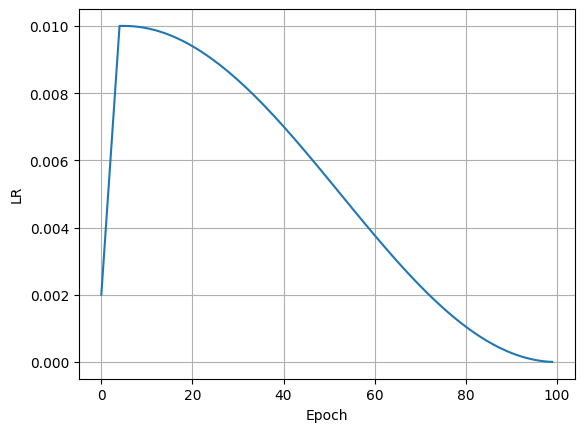

In [ ]:
import matplotlib.pyplot as plt

scheduler = CosineScheduler(epochs=100, lr=0.01)
x = np.arange(100)
plt.plot(x, [scheduler(epoch) for epoch in x])
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.grid(True)

plt.show()

また，optimizerの学習率をepochごとに更新する必要が有ります．そこでoptimizerの学習率を変更できる関数を実装しておきましょう．

---
Also, it is necessary to update the learning rate of the optimizer every epoch. Therefore, let's implement a function that can change the learning rate of the optimizer.


In [ ]:
def set_lr(lr, optimizer):
    for param_group in optimizer.param_groups:
        param_group["lr"] = lr

## 4.学習・推論

モデルの実装やその他必要な関数を実装したので，実際にモデルを学習してみましょう．まずはハイパーパラメータの設定やモデルの定義を行っていきます．

---
## 4.Learning/Inference

Now that we have implemented the model and other necessary functions, let's actually learn the model. First, we will set hyperparameters and define the model.


In [ ]:
# Setting hyperparameters
config = {
    "image_size": [32, 32],
    "patch_size": [2, 2],
    "emb_dim": 192,
    "enc_layers": 12,
    "enc_heads": 3,
    "enc_dim_head": 64,
    "enc_mlp_dim": 192,
    "dec_layers": 4,
    "dec_heads": 3,
    "dec_dim_head": 64,
    "dec_mlp_dim": 192,
    "mask_ratio": 0.75,
    "dropout": 0.
}

In [ ]:
# Model definition
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MAE_ViT(**config).to(device)

epochs = 2000
lr = 0.0024
warmup_length = 200
batch_size = 512
step_count = 0
optimizer = optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.05)
scheduler = CosineScheduler(epochs, lr, warmup_length)

次にデータを用意しましょう．今回はCIFAR-10を利用します．

---
Next, let's prepare the data. This time we will use CIFAR-10.


In [ ]:
train_transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(0.5, 0.5)]
)
valid_transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(0.5, 0.5)]
)

train_dl = torch.utils.data.DataLoader(
    datasets.CIFAR10(
        "./",
        train=True,
        download=True,
        transform=train_transform,
    ),
    batch_size=batch_size,
    shuffle=True
)
valid_dl = torch.utils.data.DataLoader(
    datasets.CIFAR10(
        "./",
        train=False,
        download=True,
        transform=valid_transform,
    ),
    batch_size=batch_size,
    shuffle=False
)

ここからモデルの学習を行っていきます．学習自体は基本的なものと同様ですが，損失関数の計算部分に注意が必要です．

画像の再構成では画像全体で損失関数を計算することも可能ですが，MAEではマスクをかけた部分の損失関数のみを計算しモデルを更新します．そのため損失関数を計算する前にモデルから出力されるmaskをもとの画像を再構成された画像にかける必要があります．

今回はdriveに学習済みモデルがあるので，実際に学習を行わなくても大丈夫です．

---
We will start learning the model from here. The learning itself is basically the same, but you need to be careful about the calculation part of the loss function.

In image reconstruction, it is possible to calculate the loss function for the entire image, but in MAE, the loss function is calculated only for the masked part and the model is updated. Therefore, before calculating the loss function, it is necessary to apply the mask output from the model to the original image and the reconstructed image.

This time, there is a trained model in drive, so there is no need to actually train it.


In [ ]:
for epoch in range(epochs):
    # Update learning rate in scheduler
    new_lr = scheduler(epoch)
    set_lr(new_lr, optimizer)

    total_train_loss = 0.
    total_valid_loss = 0.

    # training the model
    for x, _ in train_dl:
        step_count += 1
        model.train()
        x = x.to(device)

        rec_img, mask = model(x)
        train_loss = torch.mean((rec_img - x) ** 2 * mask) / config["mask_ratio"]
        train_loss.backward()

        if step_count % 8 == 0:  # By updating every 8 iterations, the batch size is artificially increased.
            optimizer.step()
            optimizer.zero_grad()

        total_train_loss += train_loss.item()

    # Model evaluation
    with torch.no_grad():
        for x, _ in valid_dl:
            model.eval()

            with torch.no_grad():
                x = x.to(device)

                rec_img, mask = model(x)
                valid_loss = torch.mean((rec_img - x) ** 2 * mask) / config["mask_ratio"]

                total_valid_loss += valid_loss.item()


    print(f"Epoch[{epoch+1} / {epochs}] Train Loss: {total_train_loss/len(train_dl):.4f} Valid Loss: {total_valid_loss/len(valid_dl):.4f}")

# save the model
torch.save(model.state_dict(), "/content/drive/MyDrive/Colab Notebooks/DLBasics2026_colab/Lecture10/model/MAE_pretrain_params.pth")

学習が終わったら実際に再構成される画像を見てみましょう．まず保存したモデルを読み込み，`valid_dl`から1バッチ分データを取得し推論します．

---
After learning, let's take a look at the actually reconstructed image. First, load the saved model, obtain one batch of data from `valid_dl`, and perform inference.


In [ ]:
model = MAE_ViT(**config).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/DLBasics2026_colab/Lecture10/model/MAE_pretrain_params.pth", map_location=device))

model.eval()
x, _ = next(iter(valid_dl))
with torch.no_grad():
    rec_img, mask = model(x.to(device))

x, rec_img, mask = x.to("cpu"), rec_img.to("cpu"), mask.to("cpu")

次に推論結果を描画してみます．もとのデータを平均0.5，標準偏差0.5で標準化している影響で画素値が0-1ではなくなっているため，まずこれをもとに戻してから描画します．

---
Next, let's draw the inference results. Because the original data has been standardized with an average of 0.5 and a standard deviation of 0.5, the pixel values ​​are no longer 0-1, so first restore this to the original before drawing.


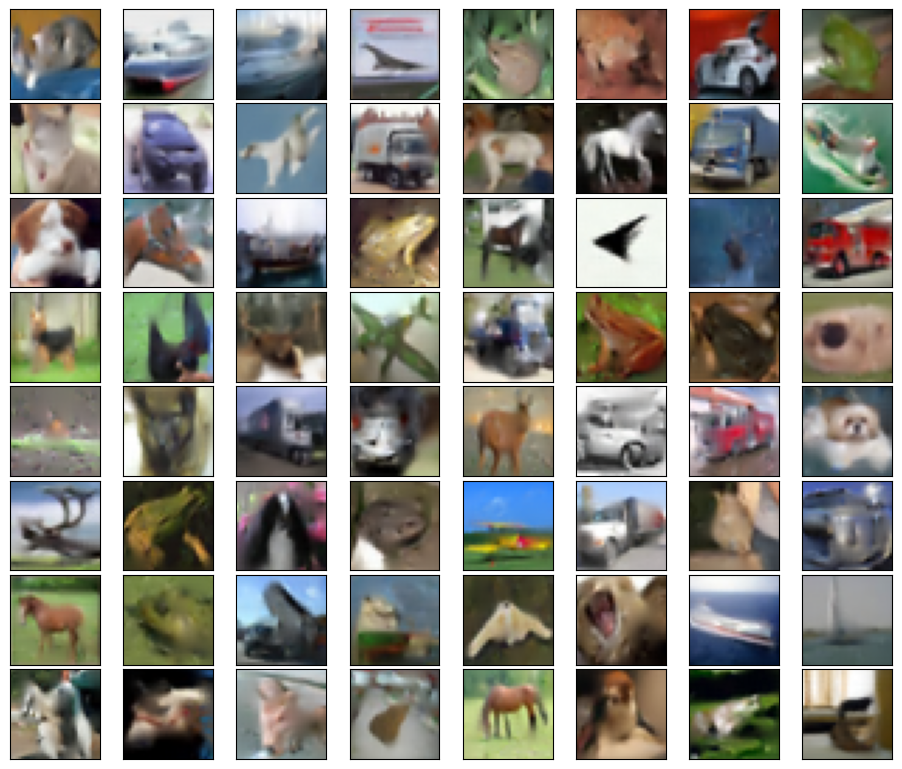

In [ ]:
fig = plt.figure(figsize=(9, 15))
fig.subplots_adjust(left=0, right=1, bottom=0, top=0.5, hspace=0.05,
                    wspace=0.05)

# When visualizing MAE output as it is
# imgs = rec_img

# Use the original image for the masked part
imgs = rec_img * mask + x * (1 - mask)
imgs = (imgs.data + 1) / 2  # Return from standardized state to 0-1
i = 0
for img in imgs[:64]:
    # Clip because the output is not necessarily 0-1 due to linear transformation
    img = np.clip(np.transpose(torch.squeeze(img).numpy(), (1, 2, 0)), 0, 1)
    ax = fig.add_subplot(8, 8, i+1, xticks=[], yticks=[])
    ax.imshow(img)
    i += 1

以下に実際の画像も描画しています．比較してみると，一部ぼやけていたり色合いなどが異なる部分もありますがある程度画像を復元できていることがわかると思います．

---
The actual image is also drawn below. If you compare them, you will see that the image has been restored to a certain extent, although some parts are blurry and the colors are different.


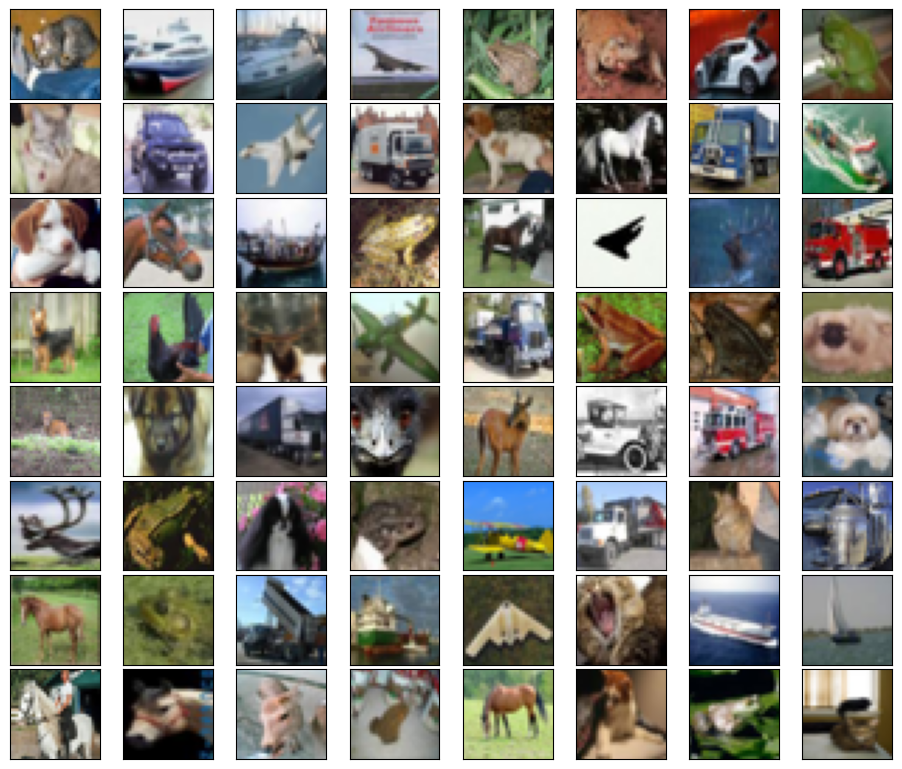

In [ ]:
fig = plt.figure(figsize=(9, 15))
fig.subplots_adjust(left=0, right=1, bottom=0, top=0.5, hspace=0.05,
                    wspace=0.05)

i = 0
imgs = (x.data + 1) / 2
for img in imgs[:64]:
    img = np.clip(np.transpose(torch.squeeze(img).numpy(), (1, 2, 0)), 0, 1)
    ax = fig.add_subplot(8, 8, i+1, xticks=[], yticks=[])
    ax.imshow(img)
    i += 1

## 5.attention mapの可視化
次に表現を獲得するときに，モデルが画像のどの部分に注目しているのかattention mapを可視化して確認してみます．  
今回はEncoderの一番最後のattention mapを可視化してみます．attention mapはheadごとに計算を行っているため，それぞれを見てみましょう．

---
## 5.Visualization of attention map
Next, let's visualize the attention map and check which part of the image the model focuses on when acquiring the expression.
This time, I will visualize the last attention map of the Encoder. The attention map is calculated for each head, so let's take a look at each one.


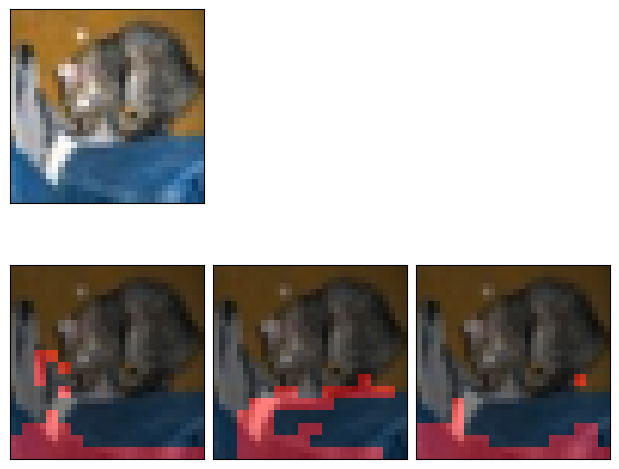

In [ ]:
def display_attn_map(model, x):
    # Get Encoder's last attention map
    attn = model.get_last_selfattention(x[0].unsqueeze(0).to(device))

    # N is the number of patches
    # (1, num_head, N+1, N+1) -> (num_head, N)
    num_head = config["enc_heads"]
    attn = attn[0, :, 0, 1:].reshape(num_head, -1)  # Extract score for cls token

    val, idx = torch.sort(attn)  # Sort scores in ascending order
    val /= torch.sum(val, dim=1, keepdim=True)  # Normalize the score by [0-1]

    # Take the cumulative sum and leave the total score at about 0.6.
    cumval = torch.cumsum(val, dim=1)
    attn = cumval > (1 - 0.4)
    backward_indexes = torch.argsort(idx)

    # return sorted
    for head in range(num_head):
        attn[head] = attn[head][backward_indexes[head]]

    # Make the score into an image
    w_featmap, h_featmap = config["image_size"][0] // config["patch_size"][0], config["image_size"][1] // config["patch_size"][1]
    attn = attn.reshape(num_head, h_featmap, w_featmap).float()

    # Make it the same size as the input image
    attn = nn.functional.interpolate(attn.unsqueeze(0), scale_factor=config["patch_size"][0], mode="nearest")[0].detach().cpu().numpy()

    # Output the input image and attention map for each head
    fig = plt.figure(figsize=(6, 10))
    fig.subplots_adjust(left=0, right=1, bottom=0, top=0.5, hspace=0.05,
                        wspace=0.05)

    img = (x[0].data + 1) / 2
    img = np.clip(np.transpose(torch.squeeze(img).numpy(), (1, 2, 0)), 0, 1)
    ax = fig.add_subplot(2, 3, 1, xticks=[], yticks=[])
    ax.imshow(img)

    for i in range(len(attn)):
        featmap = attn[i]
        featmap = np.concatenate((featmap[:,:,np.newaxis], np.zeros((32, 32, 2))), axis=2)
        ax = fig.add_subplot(2, 3, i+4, xticks=[], yticks=[])
        ax.imshow(img)
        ax.imshow(featmap, alpha=0.5)


model = MAE_ViT(**config).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/DLBasics2026_colab/Lecture10/model/MAE_pretrain_params.pth", map_location=device))
model.eval()
x, _ = next(iter(valid_dl))  # Get data from validation data

display_attn_map(model, x)

教師あり学習を用いた場合はどのようなattention mapが得られるのでしょうか？  
事前に教師あり学習でモデルを学習（第8回演習参照）したときのパラメータを準備しているので，こちらを用いて同様にattention mapを可視化してみましょう．  

MAEとは異なりクラス分類をするためのアーキテクチャになるので別にモデルを定義しておきます．

---
What kind of attention map can be obtained when using supervised learning?
Since we have prepared the parameters for learning the model using supervised learning in advance (see Exercise 8), let's use these to visualize the attention map in the same way.

Unlike MAE, this is an architecture for class classification, so a separate model will be defined.


In [ ]:
class ViT_Classifier(nn.Module):
    def __init__(self, encoder: MAE_Encoder, num_classes=10):
        super().__init__()
        self.cls_token = encoder.cls_token
        self.pos_embedding = encoder.pos_embedding
        self.patchify = encoder.patchify
        self.transformer = encoder.transformer
        self.layer_norm = encoder.layer_norm
        self.head = nn.Linear(self.pos_embedding.shape[-1], num_classes)

    def forward(self, img):
        with torch.no_grad():  # The encoder part does not calculate gradients.
          patches = self.patchify(img)
          patches = patches + self.pos_embedding  # positional embedding

          patches = torch.cat([self.cls_token.repeat(patches.shape[0], 1, 1), patches], dim=1)  # Combine class tokens
          features = self.layer_norm(self.transformer(patches))
        logits = self.head(features[:, 0])  # Enter only cls token
        return logits

    def get_last_selfattention(self, x):
        patches = self.patchify(x)
        patches = patches + self.pos_embedding

        patches = torch.cat([self.cls_token.repeat(patches.shape[0], 1, 1), patches], dim=1)  # Combine class tokens
        for i, block in enumerate(self.transformer):
            if i < len(self.transformer) - 1:
                patches = block(patches)
            else:
                return block(patches, return_attn=True)

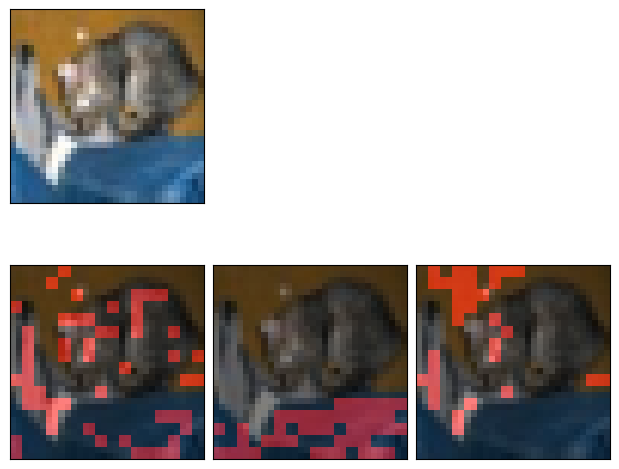

In [ ]:
mae = MAE_ViT(**config).to(device)
encoder = mae.encoder

# Model definition
model = ViT_Classifier(encoder).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/DLBasics2026_colab/Lecture10/model/ViT_supervised_params.pth", map_location=device))
model.eval()

display_attn_map(model, x)

教師あり学習の場合はMAEのattention mapとは異なり，どのheadでも画像の様々な箇所のスコアが大きくなっていることがわかります．

また，今回はそこまできれいに出てはいませんが，他の自己教師あり学習の1つである[DINO](https://arxiv.org/pdf/2104.14294.pdf)では差が明確に出ており，DINOで学習した場合は物体が写っているパッチに対してスコアが大きい部分が集中します．  

![DINO result](https://drive.google.com/uc?id=1gYbTFmW2yLB62lBCQxm-sb0CVzEJmNCk)

---
In the case of supervised learning, unlike MAE's attention map, you can see that the scores at various parts of the image are large for every head.

Also, although the result is not as clear this time, the difference is clear in [DINO] (https://arxiv.org/pdf/2104.14294.pdf), which is one of the other self-supervised learning methods, and when learning with DINO, the parts with high scores are concentrated on patches that contain objects.

![DINO result](https://drive.google.com/uc?id=1gYbTFmW2yLB62lBCQxm-sb0CVzEJmNCk)


## 6.Linear probing
ここまでやってきたことは，MAEの事前学習に当たります．  
最後に事前学習したMAEのEncoderが獲得した表現がどれだけ良いのか評価をしましょう．

今回はLinear probingによって評価します．Linear probingはEncoderの次に分類を行うための線形層を加え，線形層のみを学習する方法です．

---
## 6.Linear probing
What we have done so far corresponds to pre-learning for MAE.
Finally, let's evaluate how good the expressions acquired by the pre-trained MAE encoder are.

This time, we will evaluate using linear probing. Linear probing is a method that adds a linear layer for classification after the encoder and learns only the linear layer.


実際にLinear probingで評価してみましょう．まずはハイパーパラメータなどの設定と，データローダを定義します．モデルはattention mapの可視化時に利用したものを用います．  

Linear probingでは出力層のみを学習するため，optimizerには出力層のパラメータのみを渡すことに注意してください．  
また損失関数は，事前学習では再構成誤差を用いていましたが，Linear probingではクラス分類になるためcross entropy lossを利用します．  

---
Let's actually evaluate it using Linear probing. First, set hyperparameters and define the data loader. The model used is the one used when visualizing the attention map.

Note that linear probing only learns the output layer, so only the parameters of the output layer are passed to the optimizer.
In addition, the loss function used reconstruction error in pre-training, but since linear probing involves class classification, cross entropy loss is used.


In [ ]:
# If you run the code after pre-learning, you will run out of memory.
# Therefore, after pre-learning, please free up memory before running Linear probing.
del model
torch.cuda.empty_cache()

In [ ]:
# Setting hyperparameters
config = {
    "image_size": [32, 32],
    "patch_size": [2, 2],
    "emb_dim": 192,
    "enc_layers": 12,
    "enc_heads": 3,
    "enc_dim_head": 64,
    "enc_mlp_dim": 192,
    "dec_layers": 4,
    "dec_heads": 3,
    "dec_dim_head": 64,
    "dec_mlp_dim": 192,
    "mask_ratio": 0.75,
    "dropout": 0.
}

device = "cuda" if torch.cuda.is_available() else "cpu"
pretrained_model = MAE_ViT(**config).to(device)
pretrained_model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/DLBasics2026_colab/Lecture10/model/MAE_pretrain_params.pth", map_location=device))

encoder = pretrained_model.encoder

# Model definition
model = ViT_Classifier(encoder).to(device)

epochs = 100
lr = 0.0005
warmup_length = 5
batch_size = 128
optimizer = optim.AdamW(model.head.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=0.05)  # Learning only the classifier part
scheduler = CosineScheduler(epochs, lr, warmup_length)
criterion = nn.CrossEntropyLoss()

In [ ]:
train_transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(0.5, 0.5)]
)
valid_transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(0.5, 0.5)]
)

train_dl = torch.utils.data.DataLoader(
    datasets.CIFAR10(
        "./",
        train=True,
        download=True,
        transform=train_transform,
    ),
    batch_size=batch_size,
    shuffle=True
)
valid_dl = torch.utils.data.DataLoader(
    datasets.CIFAR10(
        "./",
        train=False,
        download=True,
        transform=valid_transform,
    ),
    batch_size=batch_size,
    shuffle=False
)

準備ができたので分類器を学習させてみましょう．事前学習では明示的に分類できるような表現を学習しているわけではないですが，得られた表現を用いることでクラス分類ができていることがわかります．

---
Now that we are ready, let's train the classifier. Although pre-learning does not learn expressions that can be explicitly classified, it can be seen that class classification is achieved by using the obtained expressions.


In [ ]:
for epoch in range(epochs):
    new_lr = scheduler(epoch)
    set_lr(new_lr, optimizer)

    total_train_loss = 0.
    total_train_acc = 0.
    total_valid_loss = 0.
    total_valid_acc = 0.
    for x, t in train_dl:
        x, t = x.to(device), t.to(device)
        pred = model(x)

        train_loss = criterion(pred, t)
        train_acc = (torch.argmax(pred, dim=1) == t).float().mean().cpu()

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        total_train_loss += train_loss.item()
        total_train_acc += train_acc

    with torch.no_grad():
        for x, t in valid_dl:
            x, t = x.to(device), t.to(device)
            pred = model(x)

            valid_loss = criterion(pred, t)
            valid_acc = (torch.argmax(pred, dim=1) == t).float().mean().cpu()

            total_valid_loss += valid_loss.item()
            total_valid_acc += valid_acc

    print(f"Epoch[{epoch+1} / {epochs}]",
          f"Train Loss: {total_train_loss/len(train_dl):.4f}",
          f"Train Acc.: {total_train_acc/len(train_dl):.4f}",
          f"Valid Loss: {total_valid_loss/len(valid_dl):.4f}",
          f"Valid Acc.: {total_valid_acc/len(valid_dl):.4f}")

torch.save(model.state_dict(), "/content/drive/MyDrive/Colab Notebooks/DLBasics2026_colab/Lecture10/model/MAE_classifier_params.pth")

Epoch[1 / 100] Train Loss: 2.1429 Train Acc.: 0.4179 Valid Loss: 2.0106 Valid Acc.: 0.5576
Epoch[2 / 100] Train Loss: 1.7951 Train Acc.: 0.6304 Valid Loss: 1.6192 Valid Acc.: 0.6613
Epoch[3 / 100] Train Loss: 1.4308 Train Acc.: 0.6736 Valid Loss: 1.2981 Valid Acc.: 0.6781
Epoch[4 / 100] Train Loss: 1.1728 Train Acc.: 0.6877 Valid Loss: 1.0993 Valid Acc.: 0.6912
Epoch[5 / 100] Train Loss: 1.0177 Train Acc.: 0.6991 Valid Loss: 0.9834 Valid Acc.: 0.6995
Epoch[6 / 100] Train Loss: 0.9292 Train Acc.: 0.7100 Valid Loss: 0.9205 Valid Acc.: 0.7080
Epoch[7 / 100] Train Loss: 0.8767 Train Acc.: 0.7174 Valid Loss: 0.8808 Valid Acc.: 0.7126
Epoch[8 / 100] Train Loss: 0.8414 Train Acc.: 0.7235 Valid Loss: 0.8536 Valid Acc.: 0.7185
Epoch[9 / 100] Train Loss: 0.8157 Train Acc.: 0.7288 Valid Loss: 0.8329 Valid Acc.: 0.7227
Epoch[10 / 100] Train Loss: 0.7963 Train Acc.: 0.7328 Valid Loss: 0.8173 Valid Acc.: 0.7269
Epoch[11 / 100] Train Loss: 0.7808 Train Acc.: 0.7362 Valid Loss: 0.8052 Valid Acc.: 0.72

In [ ]:
# Implementation of Feed-Forward Network
class FFN(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.):
        """
        Arguments
        ---------
        dim : int
            入力データの次元数．
        hidden_dim : int
            隠れ層の次元．
        dropout : float
            各全結合層の後のDropoutの確率(default=0.)．
        """
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_features=dim, out_features=hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(in_features=hidden_dim, out_features=dim),
            nn.Dropout(dropout),
        )  # MLP with one hidden layer and uses GELU as the activation function

    def forward(self, x):
        """
        (B, D) -> (B, D)
        B: バッチサイズ
        D: 次元数
        """
        return self.net(x)

## 参考文献（References）
[1] [Masked Autoencoders Are Scalable Vision Learners](https://arxiv.org/pdf/2111.06377.pdf)  
[2] [AN IMAGE IS WORTH 16X16 WORDS: TRANSFORMERS FOR IMAGE RECOGNITION AT SCALE](https://arxiv.org/pdf/2010.11929.pdf)  
[3] [Emerging Properties in Self-Supervised Vision Transformers](https://arxiv.org/pdf/2104.14294.pdf)